# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [77]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [78]:
# Load the prepared dataset from Phase 3
DATA_PATH = '../data/traffic_volume_prepared.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded prepared dataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded prepared dataset: 48187 rows x 18 columns


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,year,month,day,hour,day_of_week,is_weekend,is_rush_hour,part_of_day,season,traffic_volume
0,3,288.28,0.0,0.0,40,1,24,2012-10-02 09:00:00,2012,10,2,9,1,0,1,3,0,5545
1,3,289.36,0.0,0.0,75,1,2,2012-10-02 10:00:00,2012,10,2,10,1,0,0,3,0,4516
2,3,289.58,0.0,0.0,90,1,19,2012-10-02 11:00:00,2012,10,2,11,1,0,0,3,0,4767
3,3,290.13,0.0,0.0,90,1,19,2012-10-02 12:00:00,2012,10,2,12,1,0,0,0,0,5026
4,3,291.14,0.0,0.0,75,1,2,2012-10-02 13:00:00,2012,10,2,13,1,0,0,0,0,4918


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [79]:
# TODO: Select and document your modelling techniques here.


modelling_techniques = {
    "problem_type": "Regression",
    "target_variable": "traffic_volume",
    "candidate_models": [
        {
            "name": "Linear Regression",
            "library": "sklearn.linear_model.LinearRegression",
            "justification": "Used as a simple baseline regression model to predict traffic volume and understand linear relationships between features and target.",
            "assumptions": "Assumes a linear relationship between features and target, independence of errors, and limited multicollinearity. It may not capture complex non-linear traffic patterns well."
        },
        {
            "name": "Ridge Regression",
            "library": "sklearn.linear_model.Ridge",
            "justification": "Useful when there may be correlated features. It improves Linear Regression by adding regularisation to reduce overfitting.",
            "assumptions": "Similar to Linear Regression, but handles multicollinearity better through L2 regularisation."
        },
        {
            "name": "Random Forest Regressor",
            "library": "sklearn.ensemble.RandomForestRegressor",
            "justification": "A strong ensemble model that can capture non-linear relationships and interactions between traffic-related features.",
            "assumptions": "Makes fewer assumptions about data distribution and can handle complex feature relationships well."
        },
        {
            "name": "Gradient Boosting Regressor",
            "library": "sklearn.ensemble.GradientBoostingRegressor",
            "justification": "A powerful boosting model that often performs well on structured/tabular datasets and can model more complex patterns in traffic volume.",
            "assumptions": "Does not assume linearity and works well with non-linear relationships, but may require tuning to avoid overfitting."
        }
    ]
}

modelling_techniques

{'problem_type': 'Regression',
 'target_variable': 'traffic_volume',
 'candidate_models': [{'name': 'Linear Regression',
   'library': 'sklearn.linear_model.LinearRegression',
   'justification': 'Used as a simple baseline regression model to predict traffic volume and understand linear relationships between features and target.',
   'assumptions': 'Assumes a linear relationship between features and target, independence of errors, and limited multicollinearity. It may not capture complex non-linear traffic patterns well.'},
  {'name': 'Ridge Regression',
   'library': 'sklearn.linear_model.Ridge',
   'justification': 'Useful when there may be correlated features. It improves Linear Regression by adding regularisation to reduce overfitting.',
   'assumptions': 'Similar to Linear Regression, but handles multicollinearity better through L2 regularisation.'},
  {'name': 'Random Forest Regressor',
   'library': 'sklearn.ensemble.RandomForestRegressor',
   'justification': 'A strong ensemble

In [80]:
# Import the specific model classes you plan to use
# Example imports (uncomment and modify as needed):

# Classification
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier

# Regression
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Clustering
# from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering


# Model classes were already imported in Cell 1.

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [81]:
# Prepare modelling dataset
# Phase 3 should already have handled cleaning, feature engineering, and datetime processing.
# To avoid repeating preprocessing, we remove raw datetime if it still exists.

TARGET_COL = "traffic_volume"

df_model = df.copy()

if "date_time" in df_model.columns:
    df_model = df_model.drop(columns=["date_time"])
    print("Dropped raw 'date_time' column before modelling.")

X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL]

print("Feature columns used for modelling:")
print(X.columns.tolist())
print(f"Total features: {X.shape[1]}")

Dropped raw 'date_time' column before modelling.
Feature columns used for modelling:
['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'part_of_day', 'season']
Total features: 16


In [82]:
# Define test design and split the data

RANDOM_SEED = 42
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Feature matrix shape: (48187, 16)
Target vector shape: (48187,)
Training set: 38549 rows
Testing set: 9638 rows


In [83]:
# Document and justify the test design

test_design = {
    "split_ratio": f"{int((1 - TEST_SIZE) * 100)}/{int(TEST_SIZE * 100)}",
    "validation_strategy": "80/20 hold-out split for final testing, followed by GridSearchCV only after baseline model comparison",
    "random_seed": RANDOM_SEED,
    "justification": (
        "The hold-out test set provides an unbiased final evaluation. "
        "Baseline models are compared first on both training and testing data, "
        "then the strongest candidate is tuned using GridSearchCV."
    )
}

test_design

{'split_ratio': '80/20',
 'validation_strategy': '80/20 hold-out split for final testing, followed by GridSearchCV only after baseline model comparison',
 'random_seed': 42,
 'justification': 'The hold-out test set provides an unbiased final evaluation. Baseline models are compared first on both training and testing data, then the strongest candidate is tuned using GridSearchCV.'}

---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

In [84]:
# Build and train baseline models first
trained_models = {}

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_SEED
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=100,
        random_state=RANDOM_SEED
    )
}

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print("Baseline models trained successfully:")
for model_name in trained_models.keys():
    print("-", model_name)

Baseline models trained successfully:
- Linear Regression
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor


In [85]:
# Compare baseline models on BOTH training and testing data before GridSearch

baseline_results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    baseline_results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R2": r2_score(y_test, y_test_pred)
    })

baseline_results_df = pd.DataFrame(baseline_results).sort_values(
    by="Test R2", ascending=False
).reset_index(drop=True)

display(baseline_results_df)

best_baseline_name = baseline_results_df.loc[0, "Model"]
print(f"Best baseline model based on Test R2: {best_baseline_name}")

print("Insight:")
print("- Comparing train and test metrics helps identify both strong performance and possible overfitting before tuning.")
print("- The strongest baseline model is selected using test performance, not training performance alone.")
print("- Large gaps between training and testing scores may indicate overfitting.")

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Random Forest Regressor,75.920397,140.304415,0.994998,199.004004,356.240020,0.968257
1,Gradient Boosting Regressor,372.086380,564.250713,0.919096,364.875312,548.302740,0.924802
2,Linear Regression,1062.860828,1315.441204,0.560289,1063.327406,1315.230112,0.567318
3,Ridge Regression,1062.865490,1315.441213,0.560289,1063.333038,1315.232209,0.567317


Best baseline model based on Test R2: Random Forest Regressor
Insight:
- Comparing train and test metrics helps identify both strong performance and possible overfitting before tuning.
- The strongest baseline model is selected using test performance, not training performance alone.
- Large gaps between training and testing scores may indicate overfitting.


---
### Task 4: Assess Model

In [86]:
# Tune the strongest baseline model, then compare tuned vs baseline

param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_
trained_models["Tuned Random Forest Regressor"] = best_rf_model

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)
print("- Hyperparameter tuning is performed only after identifying the best untuned baseline model.")
print("- The tuned model must be compared against all previous models using the same metrics.")

final_results = []

for name, model in trained_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    final_results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, y_train_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Train R2": r2_score(y_train, y_train_pred),
        "Test MAE": mean_absolute_error(y_test, y_test_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test R2": r2_score(y_test, y_test_pred)
    })

results_df = pd.DataFrame(final_results).sort_values(
    by="Test R2", ascending=False
).reset_index(drop=True)

display(results_df)

print("Insight:")
print("- The tuned model should only be judged after being added back into the same comparison table as the untuned models.")
print("- Hyperparameter tuning is performed only after identifying the best untuned baseline model.")
print("- The tuned model must be compared against all previous models using the same metrics.")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}
Best Cross-Validation Score: 0.9598953554436781
- Hyperparameter tuning is performed only after identifying the best untuned baseline model.
- The tuned model must be compared against all previous models using the same metrics.


,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Tuned Random Forest Regressor,75.263081,138.739343,0.995109,198.541632,355.114859,0.968457
1,Random Forest Regressor,75.920397,140.304415,0.994998,199.004004,356.240020,0.968257
2,Gradient Boosting Regressor,372.086380,564.250713,0.919096,364.875312,548.302740,0.924802
3,Linear Regression,1062.860828,1315.441204,0.560289,1063.327406,1315.230112,0.567318
4,Ridge Regression,1062.865490,1315.441213,0.560289,1063.333038,1315.232209,0.567317


Insight:
- The tuned model should only be judged after being added back into the same comparison table as the untuned models.
- Hyperparameter tuning is performed only after identifying the best untuned baseline model.
- The tuned model must be compared against all previous models using the same metrics.


<Figure size 800x400 with 0 Axes>

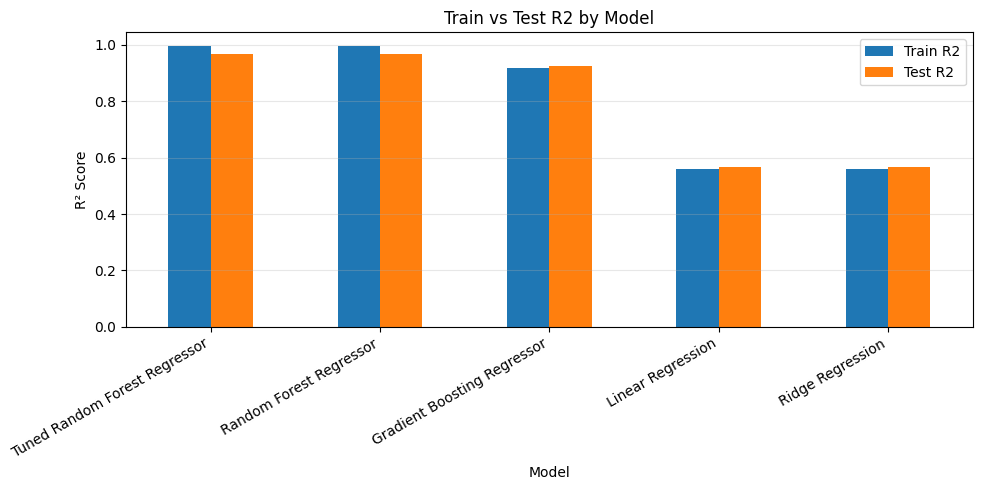

Best Model: Tuned Random Forest Regressor
Test MAE:  198.5416
Test RMSE: 355.1149
Test R²:   0.9685


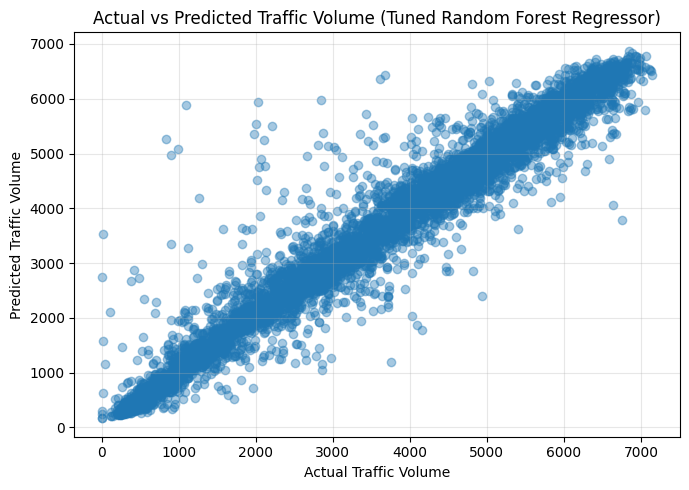

Insight:
- A smaller gap between train and test R² indicates better generalisation.
- If train performance is much higher than test performance, the model may be overfitting.


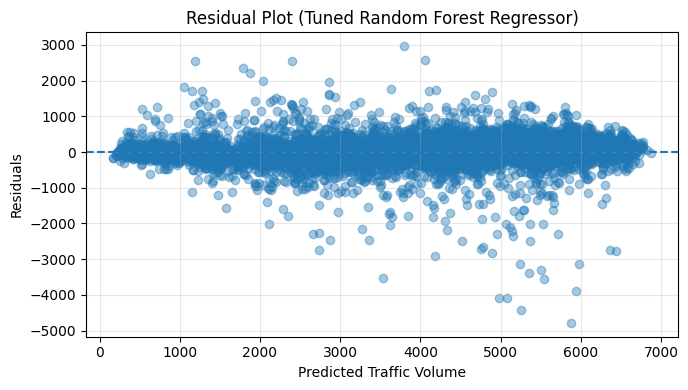

- Residuals should be randomly scattered around zero.
- Visible patterns may suggest that some structure in the data is still not being captured.


In [87]:
# Visualise final model comparison with reduced clutter and assess the best model

plt.figure(figsize=(8, 4))
comparison_plot = results_df.set_index("Model")[["Train R2", "Test R2"]]
comparison_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Train vs Test R2 by Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
y_pred_best = best_model.predict(X_test)

print(f"Best Model: {best_model_name}")
print(f"Test MAE:  {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Test R²:   {r2_score(y_test, y_pred_best):.4f}")

plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred_best, alpha=0.4)
plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title(f"Actual vs Predicted Traffic Volume ({best_model_name})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight:")
print("- A smaller gap between train and test R² indicates better generalisation.")
print("- If train performance is much higher than test performance, the model may be overfitting.")

residuals = y_test - y_pred_best

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_best, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Traffic Volume")
plt.ylabel("Residuals")
plt.title(f"Residual Plot ({best_model_name})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("- Residuals should be randomly scattered around zero.")
print("- Visible patterns may suggest that some structure in the data is still not being captured.")

In [88]:
# Cross-validation for the final selected best model

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="r2")

print("Cross-Validation R² Scores:", np.round(cv_scores, 4))
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

print("Final modelling insight:")
print("- Cross-validation is used here as a final robustness check after model selection and tuning.")
print("- A stable mean R² with low variability supports the reliability of the final model.")

Cross-Validation R² Scores: [0.9448 0.94   0.9221 0.9566 0.9396]
Mean R²: 0.9406
Standard Deviation: 0.0111
Final modelling insight:
- Cross-validation is used here as a final robustness check after model selection and tuning.
- A stable mean R² with low variability supports the reliability of the final model.
